In [1]:
import pandas as pd

df = pd.read_csv("insurance.csv")
df.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


In [2]:
print("Numerical features: age, bmi, children")
print("Categorical features: sex, smoker, region")
print("Target variable: charges")
df.dtypes

Numerical features: age, bmi, children
Categorical features: sex, smoker, region
Target variable: charges


,0
age,int64
sex,object
bmi,float64
children,int64
smoker,object
region,object
charges,float64


In [3]:
from sklearn.model_selection import train_test_split

print(df.isnull().sum())

df['sex'] = df['sex'].map({'male': 0, 'female': 1})
df['smoker'] = df['smoker'].map({'no': 0, 'yes': 1})
df = pd.get_dummies(df, columns=['region'], drop_first=True)

X = df.drop('charges', axis=1)
y = df['charges']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print(X_train.shape, X_test.shape)

age         0
sex         0
bmi         0
children    0
smoker      0
region      0
charges     0
dtype: int64
(1070, 8) (268, 8)


In [4]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()
model.fit(X_train, y_train)
y_pred = model.predict(X_test)
print("Model trained")

Model trained


MAE: 4181.194473753645
MSE: 33596915.85136143
R2 Score: 0.7835929767120725


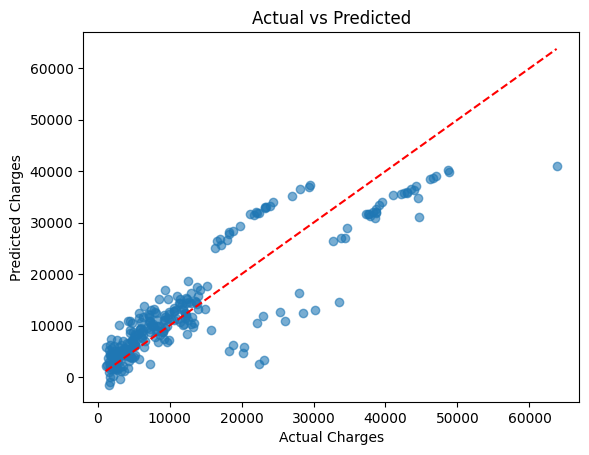

In [5]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import matplotlib.pyplot as plt

mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)
print("MAE:", mae)
print("MSE:", mse)
print("R2 Score:", r2)

plt.scatter(y_test, y_pred, alpha=0.6)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
plt.xlabel("Actual Charges")
plt.ylabel("Predicted Charges")
plt.title("Actual vs Predicted")
plt.show()

Observations:
- The model achieves an R² score of ~0.78, meaning it explains about 78% of the variance in charges.
- Smoking status has by far the largest effect on predicted charges compared to other features.
- Most points cluster near the diagonal line, but the model underpredicts for very high actual charges.

Conclusion:
This project built a Multiple Linear Regression model to predict medical insurance charges based on age, sex, BMI, number of children, smoking status, and region. The model achieved an R² score of approximately 0.78, indicating a reasonably strong fit. Smoking status emerged as the most influential factor, followed by BMI and age, while region had a comparatively minor effect. These findings align with real-world expectations, as smokers and older individuals with higher BMI generally incur higher medical costs.

One key limitation of Linear Regression here is its assumption of a linear relationship between features and charges. In reality, the interaction between smoking and BMI has a non-linear, compounding effect on costs, which a linear model cannot fully capture. More flexible models like polynomial regression or tree-based methods could improve predictive accuracy.